<center>
<h1>COMP3242/6242: Deep Learning</h1>
<h2>Lab 10: Deep Reinforcement Learning</h2>
Semester 1, 2026<br>
</center>

**Due**: 11:59pm on Sunday 17 May, 2026.<br>

Submit solutions as a single Jupyter Notebook via Canvas. Make sure that your name and student ID appears in the section below. You may not work with any other person in completing this laboratory. You must acknowledge any non-course texts or online material used. See the course policy on the use of generative AI tools such as ChatGPT and Claude.

This assignment will be **automatically graded**. Read and follow instructions carefully!

Test code is provided for you to check your work as you progress through the assignment. Feel free to add further tests and output useful for your own debugging. Note that this code will not be run when we automatically grade your submission. We will exercise your code beyond what is provided here. Do not add any Jupyter notebook magic commands (i.e., those starting with `%` or `%%`). These may cause the autograding script to fail.

Complete all **TODOs** and delete any placeholder (`pass` and `...`).

**Run all code blocks from start to end (`Restart & Run All`) and then save your Jupyter Notebook before submitting your assignment to ensure everything works as expected.**

**IMPORTANT** Make sure you have gymnasium and some other utilities installed in your python directory: 

`pip install gymnasium`

`pip install "gymnasium[other]"` (do not remove the quotations!)

In [1]:
# TODO: Replace with your name and university ID
student_name = "Weiyi Jiang"
student_id = "u8191809"

In [2]:
import sys
import getpass

from io import open
from itertools import product


def is_notebook():
    return 'ipykernel' in sys.modules

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from train_util import EpisodeLogger, TrainConfig, set_seed
import gymnasium as gym
import os

from collections import deque
import random
from typing import Optional
import time

print("User: {} ({}, {})".format(getpass.getuser(), student_name, student_id))
print("Python Version: {}".format(sys.version))
print("PyTorch Version: {}".format(torch.__version__))


User: cichlidfish (Weiyi Jiang, u8191809)
Python Version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
PyTorch Version: 2.10.0


## MDP and the Value Iteration Algorithm
Unlike supervised learning (learning within an existing dataset), RL focuses on deploying an agent to interact with an environment (defined as a Markov Decision Process, MDP) to collect data and improve the expected cumulative reward of its policy.

Consider the 3x3 grid world example below, where the bottom left cell is denoted as (0, 0) and the top right cell is denoted as (2, 2).

The **reward** function at each cell is given as the top number in each cell,

<center>
<img src="grid_world.png" width="300" height="300">
</center>

The **actions** are: $A = \{ l, r, u, d \}$, corresponding to moving left, right, up and down respectively.

The **transition** dynamics of the environment are as follows. The agent cannot move outside of the map, if an action leads to collision with the boundary, the agent stays at the current cell. State (2, 2) is a terminal state, the game finishes and all transition probability from it should be treated as 0.

The actions are **stochastic**. Denote the number of neighbours of a cell as $n$. When executing an action, there is a 10% chance that the agent will move to a wrong neighbouring cell (diagonal cells are not neighbours). 

**Hint**: think about how many neighbours there are for each cell.

What do you expect the optimal policy is? What action would you do at each cell?

**Example**: This is an example to help you get started. For cell (1, 0), the probability of all four actions are:

For going right, the "correct" next state should be "11" but it is also possible to actually go to other neighbours ("00", "20") with probability $0.1$. Distributing the probability,
$$
\begin{aligned}
P(s'=``11" | s=``10", a=``r") &= 0.8 \\
P(s'=``00" | s=``10", a=``r") &= 0.1 \\
P(s'=``20" | s=``10", a=``r") &= 0.1 \\
\end{aligned}
$$

For going left, the "correct" next state should be "10" as it should not move (hitting boundary). The possible stochastic neighbours are "00", "10", "20" all with probability 1. Therefore, the probability is.

$$
\begin{aligned}
P(s'=``10" | s=``10", a=``l") &= 0.7 \\
P(s'=``11" | s=``10", a=``l") &= 0.1 \\
P(s'=``00" | s=``10", a=``l") &= 0.1 \\
P(s'=``20" | s=``10", a=``l") &= 0.1 \\
\end{aligned}
$$

### Task 1: Build Grid World and Solve It!
Fill the python class below, specifically, you need to construct the transition probability look up table and reward lookup table. Then implement the value iteration algorithm that computes the Q-value for each state action pairs and the optimal policy method that return the optimal action from the Q-value look up table.

In [3]:
def states_to_numpy(states):
    '''
    Convert state literals to numpy arrays, e.g '0,0' maps to [0, 0]
    '''
    return np.array([float(s) for s in states])

def numpy_to_states(inp):
    '''
    Convert numpy arrays to state string literals
    '''
    return ''.join(inp.astype(int).astype(str))

def is_outside(a, b):
    return a < 0 or b < 0 or a > 2 or b > 2

def is_neighbour(a, b, x, y):
    '''
    Check whether a given cell at (a,b) is the neighbour of a cell at (x,y)
    '''
    if is_outside(a, b):
        return False
    return abs(a - x) + abs(b - y) == 1


class GridWorld:
    def __init__(self):
        # Action
        self.A = ['l', 'r', 'u', 'd']
        
        self.action_to_delta = {
            'l': np.array([0, -1]),
            'r': np.array([0, 1]),
            'u': np.array([1, 0]),
            'd': np.array([-1, 0])
        }
        
        # States
        self.S = [
            '00', '01', '02', 
            '10', '11', '12',
            '20', '21', '22',
            ]

        self.tp = self.build_tp()
        self.rf = self.build_rf()
        self.gamma = 0.99
        self.qsa = self.value_iteration()
    
    def build_tp(self):
        '''
        Build the transition probability lookup table as a python dictionary.
        The key is encoded as (state, action, next_state)
        The value is the probability of transitioning from 'state' to 'next_state' after taking 'action'
        '''
        ks = list(product(self.S, self.A, self.S)) # forming all possible keys
        tp = dict()
        for k in ks:
            state = k[0] # state literal, e.g. '01'
            state_np = states_to_numpy(state) # state in numpy array, e.g. [0, 1]
            action = k[1] # action literal, e.g. 'u'
            action_delta = self.action_to_delta[action] # action delta in numpy, e.g. 'u' maps to '[1, 0]'
            next_state = k[2]
            next_state_np = states_to_numpy(next_state)
            
            actual_ns_np = state_np + action_delta # getting the actual next state as numpy array after taking the action
            actual_ns = numpy_to_states(actual_ns_np) # getting its state literal back

            # TODO TASK 1a: given the above, set the correct probability for each case
            # terminal state has been implemented for you
            # make use of the function `is_outside` and `is_neighbour`
    
            if state == '22':
                # handle terminal state
                tp[k] = 0.0
                continue

            if is_outside(actual_ns_np[0], actual_ns_np[1]):
                actual_ns = state

            n_neighbours = sum(
                1
                for s_prime in self.S
                if is_neighbour(
                    states_to_numpy(s_prime)[0],
                    states_to_numpy(s_prime)[1],
                    state_np[0],
                    state_np[1],
                )
            )

            prob = 0.0
            if next_state == actual_ns:
                prob += 1.0 - 0.1 * n_neighbours
            if is_neighbour(next_state_np[0], next_state_np[1], state_np[0], state_np[1]):
                prob += 0.1

            tp[k] = round(prob, 10)
    
        return tp

    def build_rf(self):
        '''
        Build the reward lookup tabl as a python dictionary.
        The keys are all possible states.
        The values are the reward for entering each state.
        '''
        reward = {}
        for s in self.S:
            # TODO TASK 1b: build the reward lookup table, for each state, assign the reward to it,
            # e.g., reward['00'] should contain the value -1.
            if s == '10':
                reward[s] = -10
            elif s == '22':
                reward[s] = 10
            else:
                reward[s] = -1
            
        return reward

    def value_iteration(self, n = 10):
        '''
        Implement the value iteration algorithm.
        Construct a Q-value lookup table that returns the Q-value for each state
        and action pairs. 
        param n: number of iterations to take
        '''
        sa_pairs = list(product(self.S, self.A))
        qsa = dict.fromkeys(sa_pairs, 0) # initialise everything to 0
        for _ in range(n):
            # TODO TASK 1c: implement the value iteration algorithm taught in the lecture,
            # index qsa with state-action pairs, e.g., qsa[('00', 'u')]. Use self.tp and self.rf
            # that you built in TASK 1a and TASK 1b. For speed advatnage, the shouls use 
            # asynchronous update, i.e., update the qsa values in-place instead of using a temporary variable to store the new qsa values.
            for s, a in sa_pairs:
                if s == '22':
                    qsa[(s, a)] = 0.0
                    continue

                qsa[(s, a)] = sum(
                    self.tp[(s, a, next_state)]
                    * (self.rf[s] + self.gamma * max(qsa[(next_state, next_action)] for next_action in self.A))
                    for next_state in self.S
                )
        return qsa

    def policy(self, s):
        '''
        Given an input state s, determine the best action to take. 
        Ties should be broken based on alphabetical orders, 'd' < 'l' < 'r' < 'u'. 
        '''
        best_a = None
        # TODO TASK 1d: query the best action to take based on the existing q values found in qsa. 
        best_a = sorted(self.A, key=lambda a: (-self.qsa[(s, a)], a))[0]
        return best_a

In [4]:
if is_notebook():
    # test transition probability
    gw = GridWorld()
    p = gw.tp[('00', 'l', '00')]
    assert p == 0.8, f"The probability of staying at 00 when executing left at 00 should be 0.8, but got {p}"
    p = gw.tp[('00', 'r', '01')]
    assert p == 0.9, f"The probability of staying at 00 when executing left at 00 should be 0.8, but got {p}"
    p = gw.tp[('11', 'r', '21')]
    assert p == 0.1, f"The probability of moving to 21 when executing right at 11 should be 0.1, but got {p}"
    p = gw.tp[('11', 'd', '01')]
    assert p == 0.7, f"The probability of moving to 01 when executing down at 11 should be 0.1, but got {p}"
    p = gw.tp[('21', 'l', '20')]
    assert p == 0.8, f"The probability of moving to 01 when executing down at 11 should be 0.1, but got {p}"

    # probability should sum to 1
    p = 0
    for k, v, in gw.tp.items():
        if k[0] == '20' and k[1] == 'l':
            p += v
    assert p == 1.0, f"Probability should sum to 1"
    print("Passed transition probability tests!")

    # test reward function
    r = gw.rf['00']
    assert r == -1, f"Reward at 00 should be -1, but got {r}"
    r = gw.rf['10']
    assert r == -10, f"Reward at 10 should be -10, but got {r}"
    r = gw.rf['22']
    assert r == 10, f"Reward at 22 should be 10, but got {r}"
    print("Passed reward function tests!")

    # test q values
    q = gw.qsa[('00', 'r')]
    assert abs(q + 6.31336) < 2e-5, f"q value for 00, r is wrong"
    q = gw.qsa[('10', 'u')]
    assert abs(q + 14.22985) < 2e-5, f"q value for 00, r is wrong"
    q = gw.qsa[('11', 'l')]
    assert abs(q + 11.64410) < 2e-5, f"q value for 00, r is wrong"
    q = gw.qsa[('22', 'd')]
    assert q == 0.0, f"q value at the terminal state should always be zero"
    print("Passed Q-value tests")

    # test optimal policy
    a = gw.policy('00')
    assert a == 'r', f"Optimal policy shoud move right at 00, but got {a}"
    a = gw.policy('01')
    assert a == 'r', f"Optimal policy shoud move right at 01, but got {a}"
    a = gw.policy('02')
    assert a == 'u', f"Optimal policy shoud move up at 02, but got {a}"
    a = gw.policy('12')
    assert a == 'u', f"Optimal policy shoud move up at 12, but got {a}"
    print("Passed optimal policy tests")

Passed transition probability tests!
Passed reward function tests!
Passed Q-value tests
Passed optimal policy tests


## Deep Reinforcement Learning
In the real world, many spaces we work with are high dimensional and continuous. Instead of building lookup tables, deep reinforcement learning (DRL) aims to use neural networks to approximate these lookup tables. 

Typically, one does not have access to the MDP components (transition probability, reward function) either. A good DRL method needs to balance exploration and exploitation. That is the agent should explore the space just enough to recover the optimal policy.

In this exercise, we will look into solving some simple robotic control problems with **Deep Q-Learning**.

It has couple components that we will build step by step.

### Task 2: Q-Network
We use MLPs to approximate the Q-value lookup table we implemented in the grid world. Fill the code below, use ReLU activation functions throughout. 

In [5]:
class _QNet(nn.Module):
    """
    Simple MLP Q-network: obs → Q(s, a) for each of the action dimension
    param: 
    - obs_dim: the observation dimension (input dimension to Q net)
    - n_actions: number of actions, (output dimension of Q net)
    - hidden: list of layer sizes each corresponding to the hidden dimension
    e.g. hidden = [64, 64] means two hidden layers with 64 neurons each.

    All activation layers should be ReLU!
    """
 
    def __init__(self, obs_dim: int, n_actions: int, hidden: list[int]) -> None:
        super().__init__()
        layers: list[nn.Module] = []
        # TODO TASK 2a:
        # construct the Q-net layers according to the class description.
        dims = [obs_dim] + hidden + [n_actions]
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [6]:
if is_notebook():
    net = _QNet(obs_dim=20, n_actions=3, hidden=[128, 128])

    # check weight dimensions of each Linear layer
    linear_layers = [m for m in net.net if isinstance(m, nn.Linear)]
    assert list(linear_layers[0].weight.shape) == [128, 20],  f"Layer 0 weight shape wrong: {list(linear_layers[0].weight.shape)}"
    assert list(linear_layers[1].weight.shape) == [128, 128], f"Layer 1 weight shape wrong: {list(linear_layers[1].weight.shape)}"
    assert list(linear_layers[2].weight.shape) == [3, 128],   f"Layer 2 weight shape wrong: {list(linear_layers[2].weight.shape)}"
    print("All layer dimension checks passed!")

    # check output shape
    dummy = torch.zeros(1, 20)
    out = net(dummy)
    assert out.shape == (1, 3), f"Output shape wrong: {list(out.shape)}"
    print("Output shape check passed!")


All layer dimension checks passed!
Output shape check passed!


### Task 3: Replay Buffer
Sequential interactions with the environment are highly correlated, we want to break it by storing individual transitions in a replay buffer. 
Later, we will sample random batches from the replay to break the correlation effects.
We implement the replay buffer as a [deque](https://docs.python.org/3/library/collections.html#collections.deque).

In [7]:
class ReplayBuffer:
    """
    Fixed-capacity circular buffer storing (s, a, r, s', done) tuples.
 
    Sampling is uniform-random (standard DQN).
    """
 
    def __init__(self, capacity: int = 50_000) -> None:
        self.buffer: deque = deque(maxlen=capacity)
 
    def push(self, obs, action, reward, next_obs, done) -> None:
        '''
        Given an interaction tuple (observation, action, reward, next_observation)
        add them into the deque buffer. 
        '''
        # TASK 3a: add the input data into the replay buffer as a tuple
        # Hint: observations should be stored as numpy arrays, 
        #       actions `a` should be int,
        #       rewards `r` should be float 
        #       and done should be boolean
        self.buffer.append((
            np.asarray(obs, dtype=np.float32),
            int(action),
            float(reward),
            np.asarray(next_obs, dtype=np.float32),
            bool(done),
        ))
 
    def sample(self, batch_size: int):
        '''
        Randomly sample `batch_size` number of data from the replay buffer,
        make sure dones are sampled as floats for later computations.
        '''
        # TODO TASK 3b: randomly sample a batch of data from the replay buffer with the given batch size 
        # Hint: what are the dimensions of observation and actions? use np.stack and np.array wisely.
        # Actions `a` should be of type np.int64, rewards `r` and `done` should be of type np.float32.
        batch = random.sample(self.buffer, batch_size)
        obs, actions, rewards, next_obs, dones = zip(*batch)
        return (
            np.stack(obs),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.stack(next_obs),
            np.array(dones, dtype=np.float32),
        )
        
 
    def __len__(self) -> int:
        return len(self.buffer)

In [8]:
if is_notebook():
    obs_dim, n_actions, batch_size = 10, 2, 2

    buf = ReplayBuffer(capacity=50_000)
    for _ in range(10):
        obs      = np.random.randn(obs_dim).astype(np.float32)
        action   = np.random.randint(n_actions)
        reward   = float(np.random.randn())
        next_obs = np.random.randn(obs_dim).astype(np.float32)
        done     = bool(np.random.randint(2))
        buf.push(obs, action, reward, next_obs, done)

    assert len(buf) == 10, f"Buffer length should be 10, got {len(buf)}"
    print(f"Buffer length: {len(buf)}  (expected: 10)")

    obs_b, actions_b, rewards_b, next_obs_b, dones_b = buf.sample(batch_size)

    assert obs_b.shape      == (batch_size, obs_dim), f"obs shape wrong: {obs_b.shape}"
    assert actions_b.shape  == (batch_size,),         f"actions shape wrong: {actions_b.shape}"
    assert rewards_b.shape  == (batch_size,),         f"rewards shape wrong: {rewards_b.shape}"
    assert next_obs_b.shape == (batch_size, obs_dim), f"next_obs shape wrong: {next_obs_b.shape}"
    assert dones_b.shape    == (batch_size,),         f"dones shape wrong: {dones_b.shape}"
    print("All dimension checks passed!")


Buffer length: 10  (expected: 10)
All dimension checks passed!


### Task 4: DQN Agent
Once we have parameterise the Q-value as a neural network. We aim to optimise the following loss,

$L(\theta) = \sum_{(s,a,r,s')\in \mathcal{D}}(r + \gamma \max_{a'} Q(s', a', \theta_{prev}) - Q(s,a; \theta))^2$

Here $\mathcal{D}$ denotes the replay data. One data corresponds to a single interaction $(s,a,r,s')$. And $\theta_{prev}$ denotes the previouse step parameter. 

In practice, we never iterate through the entire replay data, as it can be very slow, instead we use SGD and sample mini batches from the replay buffer.

In order to maintain $\theta_{prev}$, we need to build two networks, an online primary network whose parameters are to be updated via the gradient from the objective and a target network whose parameter gets synced to the primary network after updating the primary network. 

To explore, DQN uses a $\epsilon$-greedy exploration strategy and as the policy improves overall, we gradually decrease $\epsilon$ but never fully reach zero.

Carefully read through the DQNAgent and finish implementing the `select_action` and `update` methods.

In [9]:
class DQNAgent:
    """
    Deep Q-Network (Mnih et al., 2015).
 
    Key ingredients:
      - Experience replay: breaks temporal correlations in the data stream.
      - Target network: provides stable TD targets; synced every
        `target_update_freq` gradient steps.
      - ε-greedy exploration with linear decay.
 
    Update rule (per batch):
        y = r + γ · max_a' Q_target(s', a') · (1 − done)
        L = MSE(Q_online(s, a), y)
 
    Parameters
    ----------
    obs_dim            : Observation dimensionality.
    n_actions          : Number of discrete actions.
    lr                 : Adam learning rate.
    gamma              : Discount factor γ.
    epsilon_start      : Initial exploration rate.
    epsilon_end        : Final exploration rate.
    epsilon_decay_steps: Steps over which ε is annealed linearly.
    batch_size         : Mini-batch size for gradient updates.
    buffer_capacity    : Replay buffer size.
    target_update_freq : Steps between target-network hard syncs.
    hidden_sizes       : Hidden layer widths.
    device             : Torch device string.
    """
 
    def __init__(
        self,
        obs_dim: int,
        n_actions: int,
        lr: float = 1e-3,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.05,
        epsilon_decay_steps: int = 10_000,
        batch_size: int = 64,
        buffer_capacity: int = 50_000,
        target_update_freq: int = 2,
        hidden_sizes: list[int] = [128, 128],
        device: str = "cpu",
    ) -> None:
        self.n_actions          = n_actions
        self.gamma              = gamma
        self.epsilon            = epsilon_start
        self.epsilon_end        = epsilon_end
        self.epsilon_decay      = (epsilon_start - epsilon_end) / epsilon_decay_steps
        self.batch_size         = batch_size
        self.target_update_freq = target_update_freq
        self.device             = torch.device(device)

        # initialise the Q nets, replay buffer and adam optimisers
        self.online_net = _QNet(obs_dim, n_actions, hidden_sizes).to(self.device)
        self.target_net = _QNet(obs_dim, n_actions, hidden_sizes).to(self.device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()
 
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.buffer    = ReplayBuffer(buffer_capacity)
 
        self._steps    = 0
        self._last_obs: Optional[np.ndarray] = None
        self._last_action: Optional[int]     = None
 
    def select_action(self, obs: np.ndarray) -> int:
        """ε-greedy action; records obs for the upcoming store_transition call."""
        self._last_obs = np.asarray(obs, dtype=np.float32)
        if random.random() < self.epsilon:
            # TODO: TASK 4a: draw uniform random actions
            action = random.randrange(self.n_actions)
        else:
            with torch.no_grad():
                x = torch.as_tensor(self._last_obs, dtype=torch.float32, device=self.device).unsqueeze(0)
                # TODO: TASK 4b: with x as the input to our online q net, 
                # return the action with the largest q values
                action = int(self.online_net(x).argmax(dim=1).item())
        self._last_action = action
        return action
 
    def store_transition(
        self,
        obs, action: int, reward: float, next_obs, done: bool
    ) -> None:
        """Push a transition into the replay buffer."""
        self.buffer.push(obs, action, reward, next_obs, done)
 
    def update(self) -> dict[str, float]:
        """
        Sample a mini-batch and perform one gradient step on the Bellman loss.
        Returns empty dict if the buffer is not yet large enough.
        """
        if len(self.buffer) < self.batch_size:
            return {}
 
        obs, actions, rewards, next_obs, dones = self.buffer.sample(self.batch_size)

        obs = torch.as_tensor(obs, dtype=torch.float32, device=self.device)
        actions = torch.as_tensor(actions, dtype=torch.int64, device=self.device).unsqueeze(1)
        rewards = torch.as_tensor(rewards, dtype=torch.float32, device=self.device)
        next_obs = torch.as_tensor(next_obs, dtype=torch.float32, device=self.device)
        dones = torch.as_tensor(dones, dtype=torch.float32, device=self.device)

        q_values = self.online_net(obs).gather(1, actions).squeeze(1)

        with torch.no_grad():
            next_q_values = self.target_net(next_obs).max(dim=1).values
            targets = rewards + self.gamma * next_q_values * (1.0 - dones)
 
        # TODO TASK 4c: implement the DQN update equation given the mini-batch sampled from above
        # specifically, compute the q values from the online net
        # compute the targets from the target net 
        # we are only interested in updating the parameters of the online net
        # ensure there is no gradient accumulates when computing the targets, hint: use torch.no_grad()
 
        loss = nn.functional.smooth_l1_loss(q_values, targets)
 
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=10.0)
        self.optimizer.step()
 
        # Anneal ε
        self._steps += 1
        self.epsilon = max(self.epsilon_end, self.epsilon - self.epsilon_decay)
 
        # Sync target network
        if self._steps % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())
 
        return {
            "loss":    loss.item(),
            "epsilon": self.epsilon,
            "steps":   self._steps,
        }

In [10]:
if is_notebook():
    # some sanity check
    obs_dim, n_actions, batch_size = 10, 2, 2
    agent = DQNAgent(
        obs_dim = obs_dim,
        n_actions = n_actions,
        batch_size = batch_size
    )
    for _ in range(10):
        obs      = np.random.randn(obs_dim).astype(np.float32)
        action   = np.random.randint(n_actions)
        reward   = float(np.random.randn())
        next_obs = np.random.randn(obs_dim).astype(np.float32)
        done     = bool(np.random.randint(2))
        agent.store_transition(obs, action, reward, next_obs, done)

    result = agent.update()
    print(f"loss: {result['loss']}")
    print(f"epsilon: {result['epsilon']}")
    print(f"steps: {result['steps']}")

loss: 0.33172762393951416
epsilon: 0.999905
steps: 1


## DRL Training Pipeline
Unlike supervised learning settings, the DRL training pipeline generally consists of building the environment, building the agent (e.g. DQN) and let the agent to interact with the environment and trains itself.

In this task, we will use the environments provided by [Gymnasium](https://gymnasium.farama.org/), a standarad DRL benchmark simulators that consists of a wide range of environments. Specifically, we will deploy our DQN agent to solve the classic [cartpole](https://gymnasium.farama.org/environments/classic_control/cart_pole/) problem.

In Cartpole, the agent needs to balance a pole sitting on a cart by only executing fixed forces to the cart. There are two actions, 0 indicating pushing the cart to the left and 1 indicating pushing the cart to the right. The state space is 4 dimensional but continuous. Specifically, the first dimension is the cart position. The second dimension is the velocity of the cart. The third dimension is the pole angle and the last dimension is the pole's angular velocity. For more details, please read the documentation found here [cartpole](https://gymnasium.farama.org/environments/classic_control/cart_pole/).

Gymnasium has mostly handled everything for you. All you need to do is to plug your DQN agent with Gymnasium and query actions from your agent and execute the action by calling `gym.step(action)`. 

Most of the boilerplate code has been written for you already, you just need to fill the code for querying from your DQN agent in run_episode_dqn

### Task 5: Cartpole Control


  Solver : DQN
  Env    : CartPole-v1
  Device : cpu

render: False
[Ep     1] return=    9.0  avg20=    9.0  steps=   9  
[Ep    10] return=   16.0  avg20=   22.5  steps=  16  loss=18.9636  epsilon=0.9846  steps=162
[Ep    20] return=   14.0  avg20=   24.9  steps=  14  loss=197.8738  epsilon=0.9587  steps=435
[Ep    30] return=   27.0  avg20=   22.9  steps=  27  loss=395.2527  epsilon=0.9411  steps=620
[Ep    40] return=   20.0  avg20=   20.1  steps=  20  loss=912.2197  epsilon=0.9205  steps=837
[Ep    50] return=   14.0  avg20=   22.7  steps=  14  loss=2610.1042  epsilon=0.8980  steps=1074
[Ep    60] return=   15.0  avg20=   23.9  steps=  15  loss=6156.5078  epsilon=0.8752  steps=1314
[Ep    70] return=   15.0  avg20=   26.2  steps=  15  loss=7593.4385  epsilon=0.8481  steps=1599
[Ep    80] return=   16.0  avg20=   23.6  steps=  16  loss=15106.2598  epsilon=0.8304  steps=1785
[Ep    90] return=   14.0  avg20=   21.1  steps=  14  loss=15112.7812  epsilon=0.8079  steps=2022
[Ep   100]

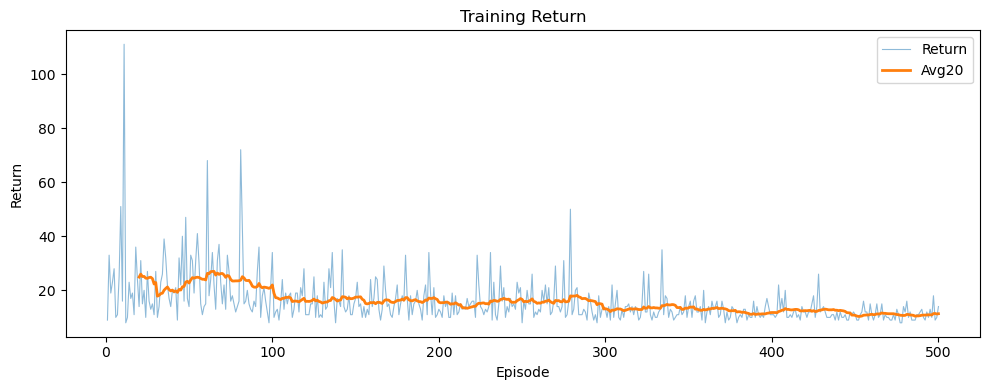

  Training time: 33.7s



In [11]:
def run_episode_dqn(env, agent: DQNAgent, max_steps: int, render: bool = False) -> tuple[float, int, dict]:
    """
    DQN: step through environment, push every transition, update after each step.
    """
    obs, _ = env.reset()
    total_reward = 0.0
    last_info: dict = {}

    if render:
        from IPython.display import clear_output

    for step in range(max_steps):
        if render:
            frame = env.render()
            clear_output(wait=True)
            plt.imshow(frame)
            plt.axis('off')
            plt.show()

        # TODO Task 5a: get actions from our agent
        action = agent.select_action(obs)

        # TODO Task 5b: sample from the environment, check the API of `env.step()`.
        next_obs, reward, terminated, truncated, _ = env.step(action)
        
        done  = terminated or truncated

        agent.store_transition(obs, action, float(reward), next_obs, done)
        info = agent.update()
        if info:
            last_info = info

        obs = next_obs
        total_reward += float(reward)
        if done:
            break

    return total_reward, step + 1, last_info

def train(cfg: TrainConfig) -> None:
    print(f"\n{'='*60}")
    print(f"  Solver : {cfg.solver.upper()}")
    print(f"  Env    : {cfg.env_id}")
    print(f"  Device : {cfg.device}")
    print(f"{'='*60}\n")
    print(f"render: {cfg.render}")

    set_seed(cfg.seed)

    render_mode = "rgb_array" if cfg.render else None
    env = gym.make(cfg.env_id, render_mode=render_mode)
    env.reset(seed=cfg.seed)
    env.action_space.seed(cfg.seed)
    obs_dim = int(np.prod(env.observation_space.shape))
    n_actions = env.action_space.n

    agent = DQNAgent(
            obs_dim             = obs_dim,
            n_actions           = n_actions,
            lr                  = cfg.lr,
            gamma               = cfg.gamma,
            epsilon_start       = cfg.epsilon_start,
            epsilon_end         = cfg.epsilon_end,
            epsilon_decay_steps = cfg.epsilon_decay_steps,
            batch_size          = cfg.batch_size,
            buffer_capacity     = cfg.buffer_capacity,
            target_update_freq  = cfg.target_update_freq,
            device              = cfg.device,
        )

    logger = EpisodeLogger(log_every=10)

    t0 = time.time()

    for ep in range(1, cfg.episodes + 1):
        ret, steps, info = run_episode_dqn(env, agent, cfg.max_steps, render=cfg.render)
        logger.record(ep, ret, steps, info)

    env.close()
    elapsed = time.time() - t0
    logger.summary()
    print(f"  Training time: {elapsed:.1f}s\n")

    return agent, logger

# Run the entire pipeline
if is_notebook():
    train_config = TrainConfig()
    train(train_config)

## (Optional): Visualising the Environment

Perhaps you might realise that there is a `render` option in `TrainConfig` we provided. This is actually one of the `gynasium` functionalities where it uses the `pygame` library to visualise the current environment -- the cartpole specifically.

**Prior to try with rendering, install `gymnasium[class-control]` with the following command by uncommenting it.**

In [12]:
if is_notebook():
  print("Uncomment the following line to download the required library for visualisation...")
  # %pip install "gymnasium[classic-control]"

Uncomment the following line to download the required library for visualisation...


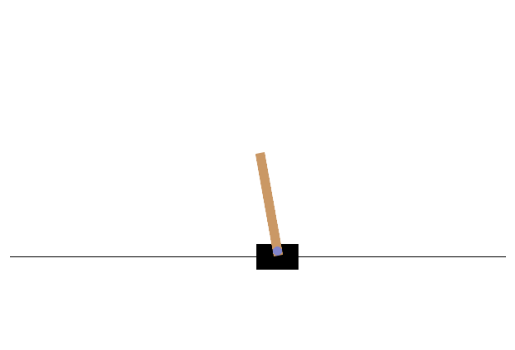

[Ep   500] return=   14.0  avg20=   11.3  steps=  14  loss=3011561.0000  epsilon=0.2563  steps=7828

  Episodes   : 500
  Mean return: 15.78
  Max return : 111.00
  Last 50 avg: 11.16


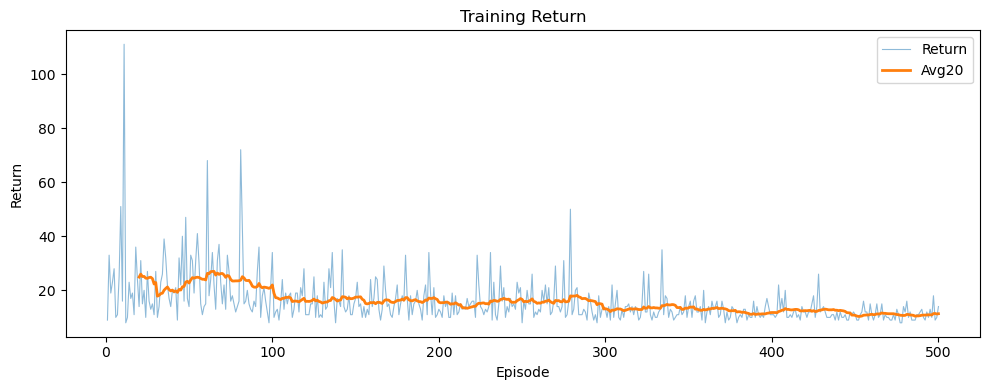

  Training time: 487.8s



In [13]:
# Training API Copied...
if is_notebook():
    train_config = TrainConfig(render=True)
    train(train_config)

In [14]:
from IPython.display import clear_output

def watch_agent(agent, episodes=3, max_steps=500):
    env = gym.make("CartPole-v1", render_mode="rgb_array")

    old_epsilon = agent.epsilon
    agent.epsilon = 0.0  # 纯贪心，不再随机探索

    returns = []
    for ep in range(episodes):
        obs, _ = env.reset()
        total_reward = 0.0

        for _ in range(max_steps):
            frame = env.render()
            clear_output(wait=True)
            plt.imshow(frame)
            plt.axis("off")
            plt.show()

            action = agent.select_action(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward

            if terminated or truncated:
                break

        returns.append(total_reward)
        print(f"Episode {ep + 1}: return = {total_reward}")

    agent.epsilon = old_epsilon
    env.close()
    print(f"Average return: {np.mean(returns):.2f}")


  Solver : DQN
  Env    : CartPole-v1
  Device : cpu

render: False
[Ep     1] return=    9.0  avg20=    9.0  steps=   9  
[Ep    10] return=   16.0  avg20=   22.5  steps=  16  loss=18.9636  epsilon=0.9846  steps=162
[Ep    20] return=   14.0  avg20=   24.9  steps=  14  loss=197.8738  epsilon=0.9587  steps=435
[Ep    30] return=   27.0  avg20=   22.9  steps=  27  loss=395.2527  epsilon=0.9411  steps=620
[Ep    40] return=   20.0  avg20=   20.1  steps=  20  loss=912.2197  epsilon=0.9205  steps=837
[Ep    50] return=   14.0  avg20=   22.7  steps=  14  loss=2610.1042  epsilon=0.8980  steps=1074
[Ep    60] return=   15.0  avg20=   23.9  steps=  15  loss=6156.5078  epsilon=0.8752  steps=1314
[Ep    70] return=   15.0  avg20=   26.2  steps=  15  loss=7593.4385  epsilon=0.8481  steps=1599
[Ep    80] return=   16.0  avg20=   23.6  steps=  16  loss=15106.2598  epsilon=0.8304  steps=1785
[Ep    90] return=   14.0  avg20=   21.1  steps=  14  loss=15112.7812  epsilon=0.8079  steps=2022
[Ep   100]

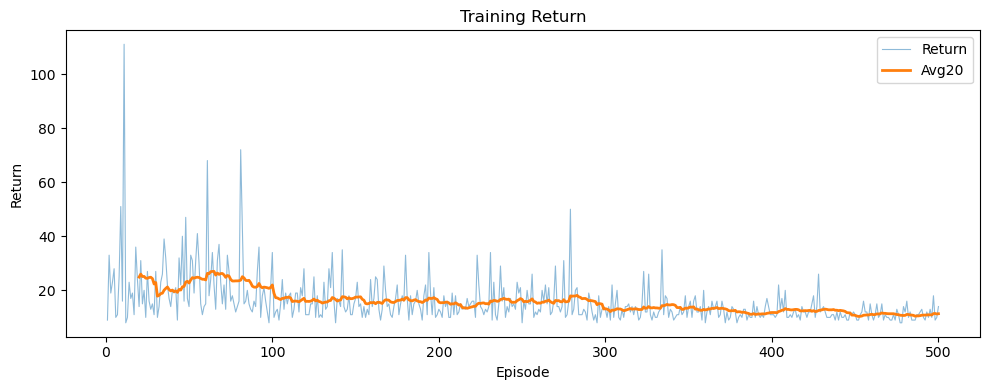

  Training time: 11.6s



In [16]:
if is_notebook():
    train_config = TrainConfig(render=False)
    agent, logger = train(train_config)

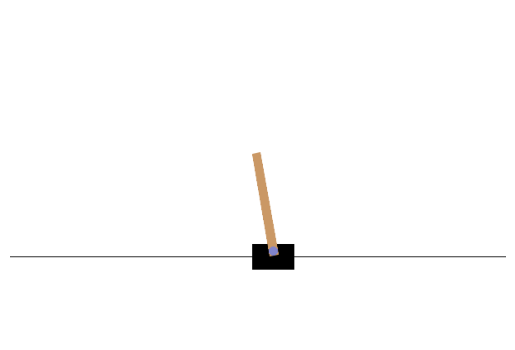

Episode 3: return = 10.0
Average return: 9.67


In [17]:
watch_agent(agent, episodes=3)